# Probabilistic evaluation

One-off analysis: does the 80% prediction interval (q10/q90, from `quantile_backtest`) actually behave like an 80% interval on the real backtest data? See `docs/decisions/0006-probabilistic-forecasting.md` for why this project uses multi-quantile LightGBM rather than conformal prediction, and why coverage + width (not a per-category breakdown) is this pass's evaluation scope.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

point_results = pd.read_parquet("../data/processed/backtest_results.parquet")
quantile_results = pd.read_parquet("../data/processed/quantile_backtest_results.parquet")

df = point_results.merge(quantile_results, on="date_heure", how="inner")

print(len(df), "rows")
print(df[["q10_pred", "q90_pred"]].isna().sum())

8303 rows
q10_pred    0
q90_pred    0
dtype: int64


## Coverage and interval width

In [2]:
covered = (df["consommation"] >= df["q10_pred"]) & (df["consommation"] <= df["q90_pred"])
coverage = covered.mean() * 100
width = (df["q90_pred"] - df["q10_pred"]).mean()

print(f"Empirical coverage: {coverage:.1f}% (target: 80%)")
print(f"Mean interval width: {width:.0f} MW")

Empirical coverage: 55.1% (target: 80%)
Mean interval width: 2795 MW


## Interval vs. actual consumption over a sample week

The first full week of the backtest window, chosen for simplicity and to avoid cherry-picking a flattering or unflattering example.

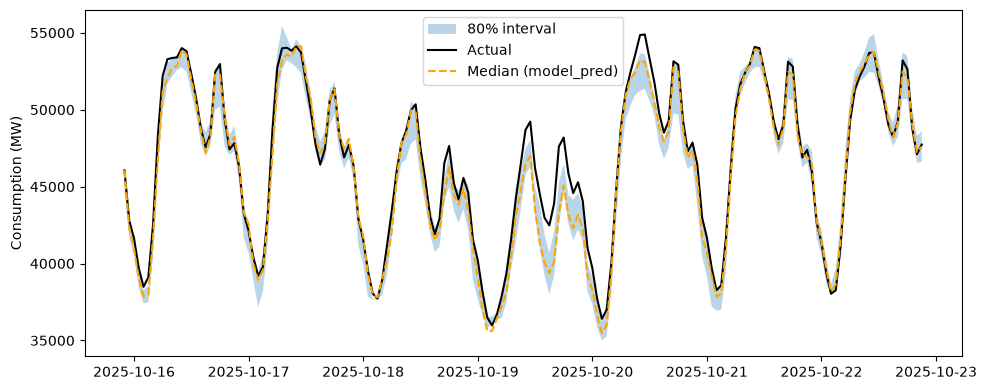

In [3]:
sample = df.set_index("date_heure").sort_index().iloc[: 24 * 7]

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    sample.index,
    sample["q10_pred"],
    sample["q90_pred"],
    alpha=0.3,
    label="80% interval",
)
ax.plot(sample.index, sample["consommation"], color="black", label="Actual")
ax.plot(
    sample.index,
    sample["model_pred"],
    color="orange",
    linestyle="--",
    label="Median (model_pred)",
)
ax.set_ylabel("Consumption (MW)")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

The empirical coverage is **55.1%** (4,579 of 8,303 backtest hours), far below the 80% target -- not a marginal miss. The interval is meaningfully overconfident: actual consumption falls above `q90_pred` 25.0% of the time and below `q10_pred` 19.8% of the time, roughly evenly split between the two tails, so this is a systematically too-narrow interval rather than a one-sided bias in either the q10 or the q90 model specifically.

The mean interval width is **2,795 MW**, giving a half-width of roughly 1,400 MW -- in the same ballpark as, and actually slightly larger than, the point forecast's own MAE of 1,286 MW. In other words, the interval is not narrow because it is trying to be aggressively tight relative to the point forecast's typical error; despite having a half-width comparable to or larger than the median model's average error, it still only captures actual demand about 55% of the time. This points to the error distribution being wider or heavier-tailed than the independently-trained q10/q90 models are capturing, not simply to an interval that was drawn too tight by design.

This is a real, disappointing finding, and per ADR 0006 it is exactly the kind of result that motivates revisiting conformal prediction: the simpler multi-quantile LightGBM approach, evaluated here for the first time against the real backtest, does not achieve reasonable calibration -- coverage is roughly 25 percentage points short of the 80% target. Conformal prediction (rejected in ADR 0006 on complexity grounds) directly targets marginal coverage by construction and would be the natural next step to close this gap, rather than treating the current multi-quantile interval as production-ready.